# Construction of A model
t分布を用いて、スパイクの影響を考慮したモデル。

今のところ考えているのは、小さなスパイクはこのモデルが効くのではということ。

## Base model
$$
\mu_t = c + \sum_{j = 1}^p \alpha_j \log S_{t-j} + \beta^T x_t
$$


## Model A: Student-t Error Model

$$
\log S_t=\mu_t+\eta_t
$$

$$
\eta_t \sim t(\nu)
$$

$$
\mathbb{E}[t(\nu)] =
\begin{cases}
0 & (\nu > 1) \\
\text{undefined} & (\nu \leq 1)
\end{cases}
$$

$$
\mathrm{Var}(t(\nu)) =
\begin{cases}
\dfrac{\nu}{\nu - 2} & (\nu > 2) \\
\infty & (1 < \nu \leq 2) \\
\text{undefined} & (\nu \leq 1)
\end{cases}
$$

# Day

In [1]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import seaborn
import statsmodels
import statsmodels.api as sm

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("seaborn:", seaborn.__version__)
print("statsmodels:", statsmodels.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
seaborn: 0.13.2
statsmodels: 0.14.6


In [2]:
tokyo = pd.read_csv(
    (PROJECT_DATA_DIR / "processed/electricity/price_tokyo.csv"),
    parse_dates=["datetime"],
    index_col="datetime",
)
tokyo36 = tokyo[tokyo["slot"] == 36].copy()
weather = pd.read_csv(
    (PROJECT_DATA_DIR / "features/electricity/temp_features.csv"),
    parse_dates=["time"],
    index_col="time",
)

In [3]:
tokyo36.head()

,slot,is_holiday,price,price_scaled,u,x
datetime,,,,,,
2016-04-01 17:30:00,36,False,10.03,10.030000,0,0.0
2016-04-02 17:30:00,36,True,7.49,9.084695,0,0.0
2016-04-03 17:30:00,36,True,6.71,8.319092,0,0.0
2016-04-04 17:30:00,36,False,9.64,9.640000,0,0.0
2016-04-05 17:30:00,36,False,8.74,8.740000,0,0.0


In [4]:
print(tokyo36.shape)

(3652, 6)


In [5]:
weather.head()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,pres,cldc,temp_mean_past,temp_centered_sq,temp_diff_abs,temp_hot,temp_cold
time,,,,,,,,,,,,,,
2016-04-01,11.7,8.3,18.1,63,0.0,NaN,13.7,1020.5,NaN,11.700000,0.000000,NaN,0.0,8.3
2016-04-02,10.9,7.9,13.3,68,4.1,NaN,9.1,1026.3,NaN,11.300000,0.160000,0.8,0.0,9.1
2016-04-03,13.0,9.7,16.7,89,NaN,NaN,10.1,1023.6,NaN,11.866667,1.284444,2.1,0.0,7.0
2016-04-04,13.9,10.0,21.9,86,6.6,NaN,13.3,1008.1,NaN,12.375000,2.325625,0.9,0.0,6.1
2016-04-05,10.9,9.7,12.3,77,NaN,NaN,8.2,1014.0,NaN,12.080000,1.392400,3.0,0.0,9.1


In [6]:
print(weather.shape)

(3652, 14)


## データセット作成

In [7]:
import numpy as np
import pandas as pd

# -------------------------
# 1. データ結合
# -------------------------

# tokyo36 の日付だけを取り出す
price_df = tokyo36.copy()
price_df["date"] = price_df.index.date

weather_df = weather.copy()
weather_df["date"] = weather_df.index.date

# 日付で結合
model_df = pd.merge(price_df, weather_df, on="date", how="inner")

# datetime を index に戻す
model_df.index = tokyo36.index[: len(model_df)]

# -------------------------
# 2. 目的変数を作成
# -------------------------

model_df["log_price"] = np.log(model_df["price_scaled"])

print(model_df.shape)
model_df.head()

(3652, 22)


,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,snwd,wspd,pres,cldc,temp_mean_past,temp_centered_sq,temp_diff_abs,temp_hot,temp_cold,log_price
datetime,,,,,,,,,,,,,,,,,,,,,
2016-04-01 17:30:00,36,False,10.03,10.030000,0,0.0,2016-04-01,11.7,8.3,18.1,...,NaN,13.7,1020.5,NaN,11.700000,0.000000,NaN,0.0,8.3,2.305581
2016-04-02 17:30:00,36,True,7.49,9.084695,0,0.0,2016-04-02,10.9,7.9,13.3,...,NaN,9.1,1026.3,NaN,11.300000,0.160000,0.8,0.0,9.1,2.206591
2016-04-03 17:30:00,36,True,6.71,8.319092,0,0.0,2016-04-03,13.0,9.7,16.7,...,NaN,10.1,1023.6,NaN,11.866667,1.284444,2.1,0.0,7.0,2.118553
2016-04-04 17:30:00,36,False,9.64,9.640000,0,0.0,2016-04-04,13.9,10.0,21.9,...,NaN,13.3,1008.1,NaN,12.375000,2.325625,0.9,0.0,6.1,2.265921
2016-04-05 17:30:00,36,False,8.74,8.740000,0,0.0,2016-04-05,10.9,9.7,12.3,...,NaN,8.2,1014.0,NaN,12.080000,1.392400,3.0,0.0,9.1,2.167910


In [8]:
model_df.tail()

,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,snwd,wspd,pres,cldc,temp_mean_past,temp_centered_sq,temp_diff_abs,temp_hot,temp_cold,log_price
datetime,,,,,,,,,,,,,,,,,,,,,
2026-03-27 17:30:00,36,False,20.69,20.690000,0,0.000000,2026-03-27,13.1,9.7,17.1,...,NaN,10.0,1013.0,5.0,16.780702,13.547565,2.1,0.0,6.9,3.029650
2026-03-28 17:30:00,36,True,20.57,25.044912,1,0.044912,2026-03-28,13.9,10.2,18.2,...,NaN,9.0,1014.4,5.0,16.779912,8.293895,0.8,0.0,6.1,3.220671
2026-03-29 17:30:00,36,True,18.92,23.036086,0,0.000000,2026-03-29,15.3,10.8,20.8,...,NaN,9.1,1017.1,4.0,16.779507,2.188941,1.4,0.0,4.7,3.137062
2026-03-30 17:30:00,36,False,18.64,18.640000,0,0.000000,2026-03-30,15.5,12.0,19.6,...,NaN,11.5,1019.9,6.0,16.779156,1.636241,0.2,0.0,4.5,2.925310
2026-03-31 17:30:00,36,False,18.39,18.390000,0,0.000000,2026-03-31,16.8,15.5,18.1,...,NaN,18.0,1009.4,8.0,16.779162,0.000434,1.3,0.0,3.2,2.911807


In [9]:
def add_log_price(df, price_col="price_scaled"):
    df = df.copy()
    df["log_price"] = np.log(df[price_col])
    return df


def add_lag_features(df, target_col="log_price", p=7):
    df = df.copy()

    for lag in range(1, p + 1):
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    return df


def add_fiscal_year(df):
    df = df.copy()

    df["fiscal_year"] = np.where(
        df.index.month >= 4, df.index.year, df.index.year - 1
    ).astype(int)

    return df


def split_train_test_by_fiscal_year(
    df,
    target_col="log_price",
    feature_cols=None,
    p=7,
    n_test_years=2,
):
    if feature_cols is None:
        feature_cols = [
            "temp",
            "temp_centered_sq",
            "temp_diff_abs",
            "temp_hot",
            "temp_cold",
        ]

    lag_cols = [f"{target_col}_lag{lag}" for lag in range(1, p + 1)]

    model_cols = [target_col] + lag_cols + feature_cols

    fiscal_years = sorted(df["fiscal_year"].unique())

    first_fiscal_year = fiscal_years[0]
    test_fiscal_years = fiscal_years[-n_test_years:]
    train_fiscal_years = fiscal_years[1:-n_test_years]

    train_df = df[df["fiscal_year"].isin(train_fiscal_years)].copy()

    test_df = df[df["fiscal_year"].isin(test_fiscal_years)].copy()

    train_df = train_df.dropna(subset=model_cols)
    test_df = test_df.dropna(subset=model_cols)

    info = {
        "first_fiscal_year_removed": first_fiscal_year,
        "train_fiscal_years": train_fiscal_years,
        "test_fiscal_years": test_fiscal_years,
        "target_col": target_col,
        "feature_cols": feature_cols,
        "lag_cols": lag_cols,
        "model_cols": model_cols,
    }

    return train_df, test_df, info

In [10]:
# -------------------------
# 実行
# -------------------------

p = 7

feature_cols = [
    "temp",
    "temp_centered_sq",
    "temp_diff_abs",
    "temp_hot",
    "temp_cold",
]

model_df = (
    model_df
    .pipe(add_log_price, price_col="price_scaled")
    .pipe(add_lag_features, target_col="log_price", p=p)
    .pipe(add_fiscal_year)
)

train_df, test_df, split_info = split_train_test_by_fiscal_year(
    model_df,
    target_col="log_price",
    feature_cols=feature_cols,
    p=p,
    n_test_years=2,
)

print("removed first fiscal year:", split_info["first_fiscal_year_removed"])
print("train fiscal years:", split_info["train_fiscal_years"])
print("test fiscal years :", split_info["test_fiscal_years"])

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)

train_df.head()

removed first fiscal year: 2016
train fiscal years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
test fiscal years : [np.int64(2024), np.int64(2025)]
train shape: (2557, 30)
test shape : (730, 30)


,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,temp_cold,log_price,log_price_lag1,log_price_lag2,log_price_lag3,log_price_lag4,log_price_lag5,log_price_lag6,log_price_lag7,fiscal_year
datetime,,,,,,,,,,,,,,,,,,,,,
2017-04-01 17:30:00,36,True,11.76,15.671103,0,0.0,2017-04-01,6.7,4.8,8.9,...,13.3,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2.743498,2017
2017-04-02 17:30:00,36,True,13.39,17.807886,0,0.0,2017-04-02,9.2,4.8,13.9,...,10.8,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2017
2017-04-03 17:30:00,36,False,14.98,14.980000,0,0.0,2017-04-03,9.5,7.4,16.0,...,10.5,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2017
2017-04-04 17:30:00,36,False,13.50,13.500000,0,0.0,2017-04-04,12.3,4.8,17.0,...,7.7,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2017
2017-04-05 17:30:00,36,False,13.00,13.000000,0,0.0,2017-04-05,15.8,7.9,20.3,...,4.2,2.564949,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2017


## 平均回帰モデル$\mu_t$の妥当性
$$
\mu_t = c + \sum_{j = 1}^p \alpha_j \log S_{t-j} + \beta^T x_t
$$

まず簡便に「平均構造はOLS、ノイズだけStudent-t」を実施
- statsmodelsのOLSでハイパーパラメータを推定。これは正規分布を仮定
- 推定ハイパーパラメータを用いて、t分布を仮定したモデルでシミュレーション

In [11]:
# -------------------------
# 1. 目的変数・説明変数
# -------------------------

target_col = "log_price"

lag_cols = [f"log_price_lag{lag}" for lag in range(1, 8)]

X_cols = lag_cols

X_train = train_df[X_cols]
y_train = train_df[target_col]

# 定数項を追加
X_train = sm.add_constant(X_train)

# -------------------------
# 2. OLS推定
# -------------------------

model_ar7 = sm.OLS(y_train, X_train)
result_ar7 = model_ar7.fit()

# -------------------------
# 3. 結果確認
# -------------------------

print(result_ar7.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     1948.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:18:47   Log-Likelihood:                 72.879
No. Observations:                2557   AIC:                            -129.8
Df Residuals:                    2549   BIC:                            -82.98
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1141      0.024      4.

In [12]:
print("AIC:", result_ar7.aic)
print("BIC:", result_ar7.bic)
print("Adj R2:", result_ar7.rsquared_adj)
print("sigma:", np.sqrt(result_ar7.scale))

AIC: -129.75714445057383
BIC: -82.98442464824434
Adj R2: 0.8420702532198936
sigma: 0.23554027987875548


In [13]:
# 4,5,6のlagは有意でないため、1,2,3,7のlagを使用してモデルを再構築してみる

# -------------------------
# 使用ラグ
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols_reduced = [f"log_price_lag{lag}" for lag in selected_lags]

# -------------------------
# 説明変数・目的変数
# -------------------------

X_train_reduced = train_df[lag_cols_reduced]

y_train = train_df["log_price"]

# 定数項
X_train_reduced = sm.add_constant(X_train_reduced)

# -------------------------
# OLS推定
# -------------------------

model_reduced = sm.OLS(y_train, X_train_reduced)

result_reduced = model_reduced.fit()

# -------------------------
# 結果確認
# -------------------------

print(result_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     3393.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:18:47   Log-Likelihood:                 66.685
No. Observations:                2557   AIC:                            -123.4
Df Residuals:                    2552   BIC:                            -94.14
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1212      0.024      5.

In [14]:
print("AIC:", result_reduced.aic)
print("BIC:", result_reduced.bic)
print("Adj R2:", result_reduced.rsquared_adj)

AIC: -123.37099168315854
BIC: -94.1380418067026
Adj R2: 0.8414899384787392


# 気温データ追加

In [15]:
temp_features = [
    "temp",
    "temp_centered_sq",
    "temp_diff_abs",
    "temp_hot",
    "temp_cold",
]

train_df[temp_features].head()

,temp,temp_centered_sq,temp_diff_abs,temp_hot,temp_cold
datetime,,,,,
2017-04-01 17:30:00,6.7,92.390964,0.5,0.0,13.3
2017-04-02 17:30:00,9.2,50.305585,2.5,0.0,10.8
2017-04-03 17:30:00,9.5,45.889579,0.3,0.0,10.5
2017-04-04 17:30:00,12.3,15.708656,2.8,0.0,7.7
2017-04-05 17:30:00,15.8,0.213594,3.5,0.0,4.2


In [16]:
# 全部入り

# -------------------------
# 1. ラグ特徴量
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols_reduced = [f"log_price_lag{lag}" for lag in selected_lags]

# -------------------------
# 2. 気温特徴量
# -------------------------

temp_features = [
    "temp",
    "temp_centered_sq",
    "temp_diff_abs",
    "temp_hot",
    "temp_cold",
]

# -------------------------
# 3. 説明変数・目的変数
# -------------------------

X_cols = lag_cols_reduced + temp_features

X_train = train_df[X_cols]
y_train = train_df["log_price"]

X_train = sm.add_constant(X_train)

# -------------------------
# 4. OLS推定
# -------------------------

model_ar137_weather_all = sm.OLS(y_train, X_train)

result_ar137_weather_all = model_ar137_weather_all.fit()

# -------------------------
# 5. 結果確認
# -------------------------

print(result_ar137_weather_all.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     1802.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:18:47   Log-Likelihood:                 133.79
No. Observations:                2557   AIC:                            -249.6
Df Residuals:                    2548   BIC:                            -197.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0014      0.000  

In [17]:
print("AIC:", result_ar137_weather_all.aic)
print("BIC:", result_ar137_weather_all.bic)
print("Adj R2:", result_ar137_weather_all.rsquared_adj)

AIC: -249.57838463217377
BIC: -196.95907485455308
Adj R2: 0.8493588635469002


特徴量に多重線形性がありそうなので、相関行列を確認してみる。

                      temp  temp_centered_sq  temp_diff_abs  temp_hot  \
temp              1.000000         -0.053624      -0.148540  0.807726   
temp_centered_sq -0.053624          1.000000      -0.127958  0.506161   
temp_diff_abs    -0.148540         -0.127958       1.000000 -0.188936   
temp_hot          0.807726          0.506161      -0.188936  1.000000   
temp_cold        -0.945674          0.353724       0.102444 -0.572169   

                  temp_cold  
temp              -0.945674  
temp_centered_sq   0.353724  
temp_diff_abs      0.102444  
temp_hot          -0.572169  
temp_cold          1.000000  


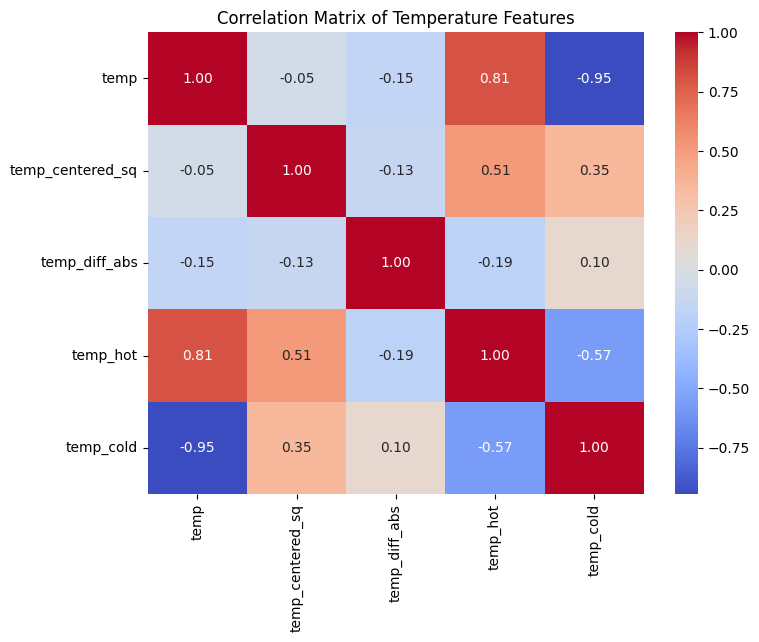

In [18]:
import seaborn as sns

# -------------------------
# 相関行列
# -------------------------

corr_matrix = train_df[temp_features].corr()

print(corr_matrix)

# -------------------------
# ヒートマップ
# -------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Temperature Features")

plt.show()

In [19]:
# temp と temp_diff_abs を消す

# -------------------------
# AR ラグ
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols = [f"log_price_lag{lag}" for lag in selected_lags]

# -------------------------
# weather(多め)
# -------------------------

weather_features_many = [
    "temp_centered_sq",
    "temp_hot",
    "temp_cold",
]

# -------------------------
# 説明変数・目的変数
# -------------------------

X_cols = lag_cols + weather_features_many

X_train = train_df[X_cols]

y_train = train_df["log_price"]

# 定数項
X_train = sm.add_constant(X_train)

# -------------------------
# OLS推定
# -------------------------

model_ar137_weather_many = sm.OLS(y_train, X_train)

result_ar137_weather_many = model_ar137_weather_many.fit()

# -------------------------
# 結果確認
# -------------------------

print(result_ar137_weather_many.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     2059.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:18:48   Log-Likelihood:                 133.01
No. Observations:                2557   AIC:                            -250.0
Df Residuals:                    2549   BIC:                            -203.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1549      0.024  

In [20]:
print("AIC:", result_ar137_weather_many.aic)
print("BIC:", result_ar137_weather_many.bic)
print("Adj R2:", result_ar137_weather_many.rsquared_adj)

AIC: -250.01871851810938
BIC: -203.24599871577988
Adj R2: 0.8493260847348358


In [21]:
# temp_centered_sqのみ

# -------------------------
# AR ラグ
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols = [f"log_price_lag{lag}" for lag in selected_lags]

# -------------------------
# weather(少なめ)
# -------------------------

weather_features_few = [
    "temp_centered_sq",
]

# -------------------------
# 説明変数・目的変数
# -------------------------

X_cols = lag_cols + weather_features_few

X_train = train_df[X_cols]

y_train = train_df["log_price"]

# 定数項
X_train = sm.add_constant(X_train)

# -------------------------
# OLS推定
# -------------------------

model_ar137_weather_few = sm.OLS(y_train, X_train)

result_ar137_weather_few = model_ar137_weather_few.fit()

# -------------------------
# 結果確認
# -------------------------

print(result_ar137_weather_few.summary())

print("AIC:", result_ar137_weather_few.aic)
print("BIC:", result_ar137_weather_few.bic)
print("Adj R2:", result_ar137_weather_few.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     2877.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:18:48   Log-Likelihood:                 130.08
No. Observations:                2557   AIC:                            -248.2
Df Residuals:                    2551   BIC:                            -213.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1381      0.023  

In [22]:
# temp と temp_centered_sqだけでやる

# -------------------------
# AR ラグ
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols = [f"log_price_lag{lag}" for lag in selected_lags]

# -------------------------
# weather(中間)
# -------------------------

weather_features_middle = [
    "temp",
    "temp_centered_sq",
]

# -------------------------
# 説明変数・目的変数
# -------------------------

X_cols = lag_cols + weather_features_middle

X_train = train_df[X_cols]

y_train = train_df["log_price"]

# 定数項
X_train = sm.add_constant(X_train)

# -------------------------
# OLS推定
# -------------------------

model_ar137_weather_middle = sm.OLS(y_train, X_train)

result_ar137_weather_middle = model_ar137_weather_middle.fit()

# -------------------------
# 結果確認
# -------------------------

print(result_ar137_weather_middle.summary())

print("AIC:", result_ar137_weather_middle.aic)
print("BIC:", result_ar137_weather_middle.bic)
print("Adj R2:", result_ar137_weather_middle.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     2397.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:18:48   Log-Likelihood:                 130.08
No. Observations:                2557   AIC:                            -246.2
Df Residuals:                    2550   BIC:                            -205.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1388      0.026  

## 結果
| Model                           |         BIC |
| ------------------------------- | ----------: |
| AR(1,2,3,7)                     |      -94.14 |
| + temp_centered_sq              | **-213.09** |
| + temp + temp_centered_sq       |     -205.24 |
| + temp_centered_sq + hot + cold |     -203.25 |

採用モデル

$$
\mu_t = c + \sum_{lag = 1 , 2 , 3 , 7} \alpha_{lag} \log S_{t-lag} + \beta (T_t - \bar{T}_t)^2
$$


In [23]:
# temp_centered_sqのみ

# -------------------------
# AR ラグ
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols = [f"log_price_lag{lag}" for lag in selected_lags]

# -------------------------
# weather(少なめ)
# -------------------------

weather_features_few = [
    "temp_centered_sq",
]

# -------------------------
# 説明変数・目的変数
# -------------------------

X_cols = lag_cols + weather_features_few

X_train = train_df[X_cols]

y_train = train_df["log_price"]

# 定数項
X_train = sm.add_constant(X_train)

# -------------------------
# OLS推定
# -------------------------

model_ar137_weather_few = sm.OLS(y_train, X_train)

result = model_ar137_weather_few.fit()

# -------------------------
# 結果確認
# -------------------------

print(result.summary())

print("AIC:", result.aic)
print("BIC:", result.bic)
print("Adj R2:", result.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     2877.
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        12:18:48   Log-Likelihood:                 130.08
No. Observations:                2557   AIC:                            -248.2
Df Residuals:                    2551   BIC:                            -213.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1381      0.023  

In [24]:
coef_df = result.params.to_frame(name="coef")
print(coef_df)

                      coef
const             0.138140
log_price_lag1    0.596653
log_price_lag2    0.085305
log_price_lag3    0.120421
log_price_lag7    0.125719
temp_centered_sq  0.000967


In [30]:
import sys
from pathlib import Path

# 保存先
output_path = PROJECT_DATA_DIR / "para/electricity/para_mu.csv"

# CSV出力
coef_df.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: ..\data\para\electricity\para_mu.csv


In [25]:
from scipy.stats import t

# -------------------------
# train残差
# -------------------------

resid_train = result.resid

# -------------------------
# Student-t 分布フィット
# loc=0 固定
# -------------------------

nu_hat, loc_hat, sigma_hat = t.fit(resid_train, floc=0)

# -------------------------
# 結果
# -------------------------

print("nu_hat    :", nu_hat)
print("loc_hat   :", loc_hat)
print("sigma_hat :", sigma_hat)

nu_hat    : 2.42652704791855
loc_hat   : 0
sigma_hat : 0.1235592108455475


かなりheavyなモデルになってしまった

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import t
from sklearn.metrics import mean_squared_error

# -------------------------
# 1. モデルで使う列
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols = [f"log_price_lag{lag}" for lag in selected_lags]

weather_features = [
    "temp_centered_sq",
]

X_cols = lag_cols + weather_features

target_col = "log_price"

# -------------------------
# 2. testデータの説明変数
# -------------------------

X_test = test_df[X_cols]
X_test = sm.add_constant(X_test)

y_test = test_df[target_col]

# -------------------------
# 3. 平均構造 mu_t を計算
# -------------------------

mu_test = result.predict(X_test)

# -------------------------
# 4. OLS残差から sigma を取得
# -------------------------

sigma_hat = np.sqrt(result.scale)

print("sigma_hat:", sigma_hat)

# -------------------------
# 5. Student-t ノイズを生成
# -------------------------

nu = nu_hat  # 先ほどフィットした自由度を使用

np.random.seed(42)

eta_sim = t.rvs(df=nu, loc=0, scale=sigma_hat, size=len(test_df))

# -------------------------
# 6. log価格をシミュレーション
# -------------------------

sim_log_price = mu_test + eta_sim

# -------------------------
# 7. 価格に戻す
# -------------------------

sim_price = np.exp(sim_log_price)

actual_price = test_df["price_scaled"]

# -------------------------
# 8. 二乗誤差
# -------------------------

squared_error = (actual_price - sim_price) ** 2

mse = squared_error.mean()
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE:", rmse)

# -------------------------
# 9. 結果データフレーム
# -------------------------

sim_result = pd.DataFrame(
    {
        "actual_price": actual_price,
        "mu_log": mu_test,
        "sim_log_price": sim_log_price,
        "sim_price": sim_price,
        "squared_error": squared_error,
    },
    index=test_df.index,
)

sim_result.head()

sigma_hat: 0.23023910133299638
MSE : 535.6508155686896
RMSE: 23.14413134184754


,actual_price,mu_log,sim_log_price,sim_price,squared_error
datetime,,,,,
2024-04-01 17:30:00,15.00,2.657378,2.802208,16.481001,2.193365
2024-04-02 17:30:00,14.35,2.696949,2.441055,11.485150,8.207367
2024-04-03 17:30:00,16.28,2.658486,2.955845,19.217958,8.631597
2024-04-04 17:30:00,15.00,2.714770,2.500690,12.190901,7.891039
2024-04-05 17:30:00,13.09,2.648258,3.009430,20.275836,51.636242


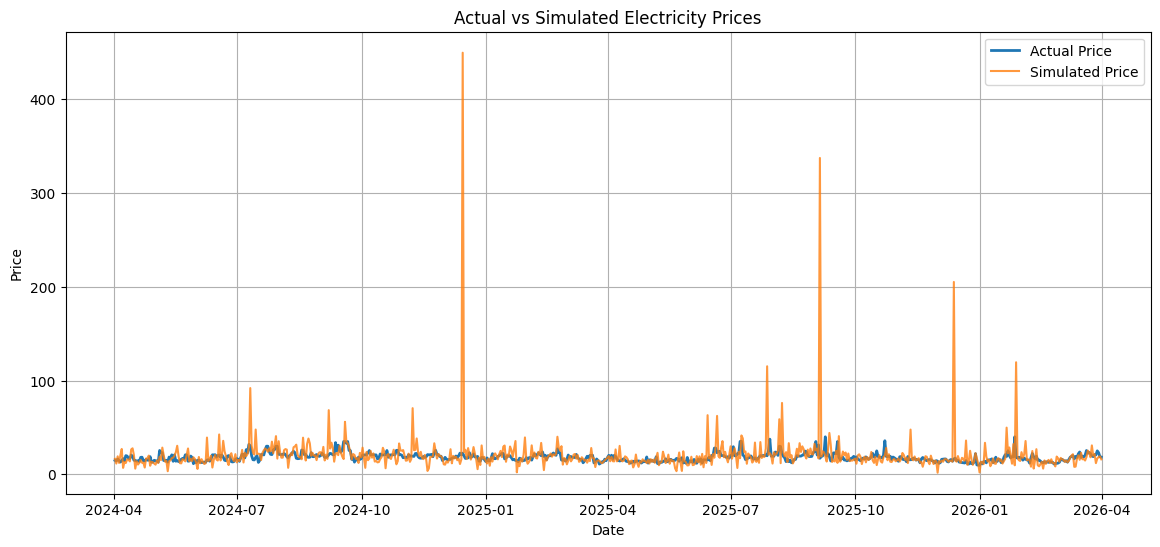

In [27]:
import matplotlib.pyplot as plt

# -------------------------
# プロット
# -------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    sim_result.index, sim_result["actual_price"], label="Actual Price", linewidth=2
)

plt.plot(sim_result.index, sim_result["sim_price"], label="Simulated Price", alpha=0.8)

plt.title("Actual vs Simulated Electricity Prices")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [28]:
import numpy as np
import pandas as pd
from scipy.stats import t

# -------------------------
# 共通設定
# -------------------------

nu_list = [7, 8, 9, 10]

np.random.seed(42)

# sigma は train 残差から推定したものを使用
# すでに sigma_hat がある前提
# sigma_hat = t.fit(result.resid, floc=0)[2]

# -------------------------
# test の平均構造
# -------------------------

selected_lags = [1, 2, 3, 7]

lag_cols = [f"log_price_lag{lag}" for lag in selected_lags]

weather_features = [
    "temp_centered_sq",
]

X_cols = lag_cols + weather_features

X_test = test_df[X_cols]
X_test = sm.add_constant(X_test)

mu_test = result.predict(X_test)

actual_price = test_df["price_scaled"]

# -------------------------
# nuごとにシミュレーション
# -------------------------

sim_results = {}

for nu in nu_list:
    eta_sim = t.rvs(df=nu, loc=0, scale=sigma_hat, size=len(test_df))

    sim_log_price = mu_test + eta_sim
    sim_price = np.exp(sim_log_price)

    squared_error = (actual_price - sim_price) ** 2

    sim_results[nu] = pd.DataFrame(
        {
            "actual_price": actual_price,
            "mu_log": mu_test,
            "sim_log_price": sim_log_price,
            "sim_price": sim_price,
            "squared_error": squared_error,
        },
        index=test_df.index,
    )

    mse = squared_error.mean()
    rmse = np.sqrt(mse)

    print(f"nu={nu}")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("-" * 30)

nu=7
MSE : 56.75711798704619
RMSE: 7.533732009239922
------------------------------
nu=8
MSE : 31.722023310414865
RMSE: 5.632230757915985
------------------------------
nu=9
MSE : 41.024884534803405
RMSE: 6.40506709838417
------------------------------
nu=10
MSE : 37.30601382698578
RMSE: 6.10786491558104
------------------------------


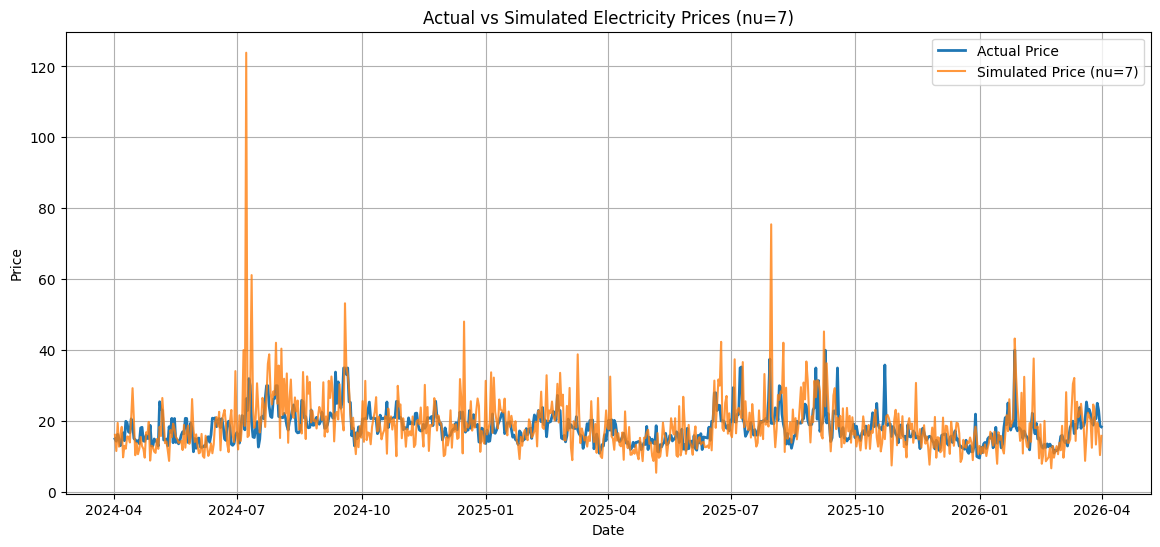

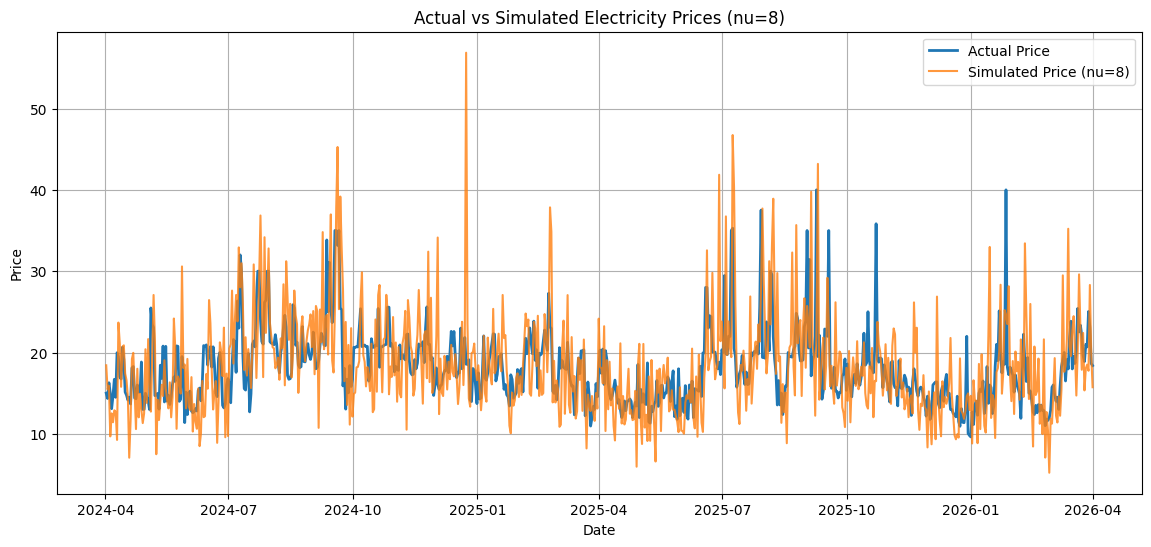

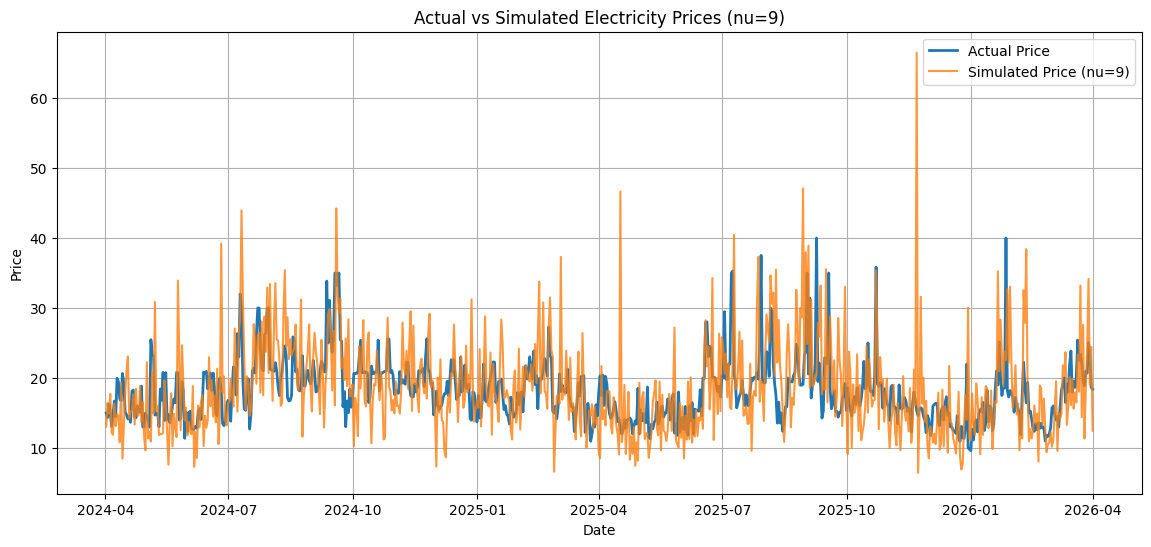

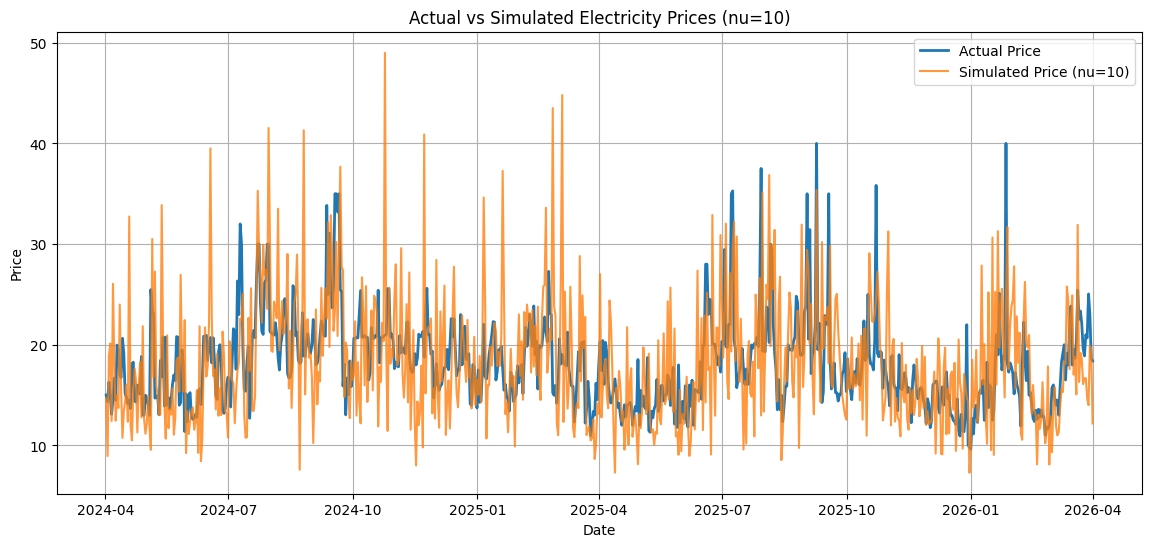

In [29]:
import matplotlib.pyplot as plt

# -------------------------
# nuごとにプロット
# -------------------------

for nu in nu_list:
    sim_df = sim_results[nu]

    plt.figure(figsize=(14, 6))

    plt.plot(sim_df.index, sim_df["actual_price"], label="Actual Price", linewidth=2)

    plt.plot(
        sim_df.index, sim_df["sim_price"], label=f"Simulated Price (nu={nu})", alpha=0.8
    )

    plt.title(f"Actual vs Simulated Electricity Prices (nu={nu})")

    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()

    plt.grid(True)

    plt.show()

このモデルだと
> はずれ値が出ているだけのモデルになっている